# Tarea 6: Modelos a tiempo continuo

### MDS7203 Modelos Generativos Profundos

**Nombre:**

**Fecha de entrega:**

En esta sexta y última tarea se evaluarán los contenidos asociados a modelos de difusión a tiempo continuo y flow matching. Para esto, se deberá responder algunas preguntas conceptuales y luego implementar la técnicas de flow matching sobre un dataset de juguete.

Algunas instrucciones generales:

- Se pueden utilizar de manera libre herramientas como ChatGPT y Claude, entre otras.
- Para la entrega, no es necesario un informe, este archivo es suficiente.
- Se debe entregar el documento con todas las celdas ejecutadas.
- Esta tarea puede ser resuelta sin usar GPU.
- La tarea está compuesta por dos partes. Ambas partes valen lo mismo.

## Parte 1: preguntas conceptuales

En esta primera parte se pedirá responder algunas preguntas conceptuales y teóricas acerca de los modelos generativos a tiempo continuo.

### Flow matching
- ¿Como se utiliza el concepto de ecuación diferencial ordinaria (EDO) en flow matching?
> **Respuesta:**
- ¿Para qué sirve la ecuación de continuidad asociada a una EDO? ¿Cómo se utiliza esta ecuación en flow matching?
> **Respuesta:**
- ¿Qué relación hay entre la técnica de rectified flows y flow matching?
> **Respuesta:**
- Escriba el funcional de costo utilizado en flow matching, indicando claramente las distribuciones sobre las que se calculan las esperanzas.
> **Respuesta:**
- Teniendo un modelo de flow matching entrenado, ¿cómo se generan nuevas muestras?
> **Respuesta:**

### Modelos de difusión

- ¿Qué es un movimiento browiano y cuáles son las propiedades que lo definen? 
> **Respuesta:**
- ¿Qué diferencia hay entre una EDO y una ecuación diferencial estocástica (SDE)?
> **Respuesta:**
- ¿Qué es la ecuación de Fokker-Planck? ¿Cómo se relaciona con la ecuación de continuidad?
> **Respuesta:**
- ¿Para qué se utiliza el teorema de inversión de Anderson en los modelos de difusión a tiempo continuo?
> **Respuesta:**
- ¿Qué relación hay entre la técnica de denoising score matching y los modelos de difusión a tiempo continuo?
> **Respuesta:**
- ¿Qué diferencia hay entre el algoritmo de Euler y el algoritmo de Euler-Maruyama?
> **Respuesta:**
- ¿Qué ventajas hay al usar la formulación continua de los modelos de difusión en vez de usar la formulación discreta (DDPM)?
> **Respuesta:**

## Parte 2: implementación de flow matching

En esta segunda parte se pedirá implementar la técnica de flow matching sobre el dataset de juguete que se utilizó a lo largo de todo el curso. Para esto, se pedirá implementar una red neuronal simple y los loops de entrenamiento y de generación de muestras.

In [1]:
import torch
from torch import nn, optim
from sklearn.datasets import make_swiss_roll
import matplotlib.pyplot as plt

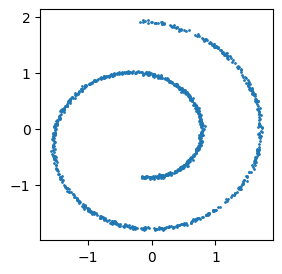

In [2]:
def get_batch(batch_size=1000, noise=0.1):
    x, _ = make_swiss_roll(batch_size, noise=noise)
    x = x[:, [0, 2]]
    x = (x - x.mean()) / x.std()
    return torch.tensor(x).float()

x = get_batch()
plt.figure(figsize=(3, 3))
plt.scatter(x[:, 0], x[:, 1], s=1)
plt.show()

- Implemente la red neuronal `VectorField` (una red fully connected es suficiente). Recuerde que esta red será la que aprenda el campo de velocidades $u_\theta:\R^D\times[0,1]\to\R^D$ asociado a la EDO de flow matching.

In [3]:
class VectorField(nn.Module):

    def __init__(self, data_dim=2):
        super().__init__()

        self.data_dim = data_dim

        self.mlp = nn.Sequential(
            nn.Linear(data_dim + 1, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, data_dim)
        )

    def forward(self, x_t, t):
        # x_t: [batch_size, data_dim]
        # t: [batch_size, 1]
        input = torch.cat([x_t, t], dim=1)
        return self.mlp(input)

- Complete los métodos `train` y `generate_samples` de la clase `FlowMatching`.

In [4]:
class FlowMatching:

    def __init__(self, velocity_net):
        self.velocity_net = velocity_net
        self.optimizer = optim.Adam(velocity_net.parameters())
        self.data_dim = velocity_net.data_dim
    
    def train(self, n_iters=5000):

        loss_fn = nn.MSELoss()

        for _ in range(n_iters):

            x_1 = get_batch()
            t = torch.rand([len(x_1), 1])
            x_0 = torch.randn_like(x_1)
            x_t = t * x_1 + (1-t) * x_0

            f_t_pred = self.velocity_net(x_t, t)
            f_t_real = x_1 - x_0

            loss = loss_fn(f_t_pred, f_t_real)
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

    def generate_samples(self, n_samples=5000, n_steps=1000):

        # Ruido inicial x_0:
        x_t = torch.randn(n_samples, self.data_dim)

        # Algoritmo de Euler para la ODE:
        timesteps = torch.linspace(0, 1, n_steps)
        dt = timesteps[1] - timesteps[0]
        for t in timesteps:
            t = torch.empty([len(x_t), 1]).fill_(t)
            x_t = x_t + self.velocity_net(x_t, t) * dt

        return x_t.detach()

Con la clase anterior bien implementada, se puede entrenar el modelo y luego generar nuevas muestras:

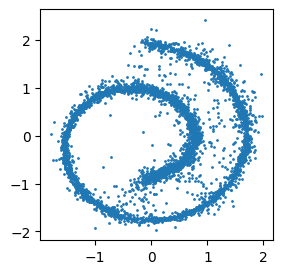

In [5]:
# Entrenamiento:
velocity_net = VectorField()
fm = FlowMatching(velocity_net)
fm.train()

# Generación:
x_1 = fm.generate_samples()
plt.figure(figsize=(3, 3))
plt.scatter(x_1[:, 0], x_1[:, 1], s=1)
plt.show()